<a href="https://colab.research.google.com/github/Raksh1707/taskdeeplearning/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Random Seed
# -----------------------------
torch.manual_seed(42)
np.random.seed(42)

In [3]:
x = torch.linspace(-2, 2, 200).reshape(-1,1)
y = x**3 + 0.3*torch.randn_like(x)
print(x,y)

tensor([[-2.0000],
        [-1.9799],
        [-1.9598],
        [-1.9397],
        [-1.9196],
        [-1.8995],
        [-1.8794],
        [-1.8593],
        [-1.8392],
        [-1.8191],
        [-1.7990],
        [-1.7789],
        [-1.7588],
        [-1.7387],
        [-1.7186],
        [-1.6985],
        [-1.6784],
        [-1.6583],
        [-1.6382],
        [-1.6181],
        [-1.5980],
        [-1.5779],
        [-1.5578],
        [-1.5377],
        [-1.5176],
        [-1.4975],
        [-1.4774],
        [-1.4573],
        [-1.4372],
        [-1.4171],
        [-1.3970],
        [-1.3769],
        [-1.3568],
        [-1.3367],
        [-1.3166],
        [-1.2965],
        [-1.2764],
        [-1.2563],
        [-1.2362],
        [-1.2161],
        [-1.1960],
        [-1.1759],
        [-1.1558],
        [-1.1357],
        [-1.1156],
        [-1.0955],
        [-1.0754],
        [-1.0553],
        [-1.0352],
        [-1.0151],
        [-0.9950],
        [-0.9749],
        [-0.

In [4]:
input_size = 1
hidden_size = 16
output_size = 1


In [7]:
def initialize():

    W1 = torch.randn(input_size, hidden_size, requires_grad=True)
    b1 = torch.zeros(hidden_size, requires_grad=True)

    W2 = torch.randn(hidden_size, output_size, requires_grad=True)
    b2 = torch.zeros(output_size, requires_grad=True)

    return [W1,b1,W2,b2]


In [8]:
# Forward Pass
def forward(params, x):

    W1,b1,W2,b2 = params

    h = torch.relu(x @ W1 + b1)
    out = h @ W2 + b2

    return out

In [9]:
# Loss Function
def loss_fn(pred,target):
    return torch.mean((pred-target)**2)


In [10]:
# Momentum Optimizer
# -----------------------------
def train_momentum():

    params = initialize()

    lr = 0.01
    beta = 0.9

    velocity = [torch.zeros_like(p) for p in params]

    losses = []

    for epoch in range(200):

        pred = forward(params,x)
        loss = loss_fn(pred,y)

        loss.backward()

        with torch.no_grad():

            for i,p in enumerate(params):

                velocity[i] = beta*velocity[i] + (1-beta)*p.grad
                p -= lr*velocity[i]

                p.grad.zero_()

        losses.append(loss.item())

    return losses


In [11]:
# RMSprop Optimizer
# -----------------------------
def train_rmsprop():

    params = initialize()

    lr = 0.01
    beta = 0.9
    eps = 1e-8

    s = [torch.zeros_like(p) for p in params]

    losses = []

    for epoch in range(200):

        pred = forward(params,x)
        loss = loss_fn(pred,y)

        loss.backward()

        with torch.no_grad():

            for i,p in enumerate(params):

                s[i] = beta*s[i] + (1-beta)*(p.grad**2)

                p -= lr*p.grad/(torch.sqrt(s[i])+eps)

                p.grad.zero_()

        losses.append(loss.item())

    return losses

In [15]:
def train_adam():

    params = initialize()

    lr = 0.01
    beta1 = 0.9
    beta2 = 0.999
    eps = 1e-8

    m = [torch.zeros_like(p) for p in params]
    v = [torch.zeros_like(p) for p in params]

    losses = []

    for epoch in range(1,201):

        pred = forward(params, x)
        loss = loss_fn(pred, y)

        loss.backward()

        with torch.no_grad():
            for i, p in enumerate(params):

                m[i] = beta1 * m[i] + (1 - beta1) * p.grad
                v[i] = beta2 * v[i] + (1 - beta2) * (p.grad ** 2)

                m_hat = m[i] / (1 - beta1 ** epoch)
                v_hat = v[i] / (1 - beta2 ** epoch)

                p -= lr * m_hat / (torch.sqrt(v_hat) + eps)

                p.grad.zero_()

        losses.append(loss.item())

    return losses

In [17]:
# Train Models
loss_momentum = train_momentum()
loss_rmsprop = train_rmsprop()
loss_adam = train_adam()

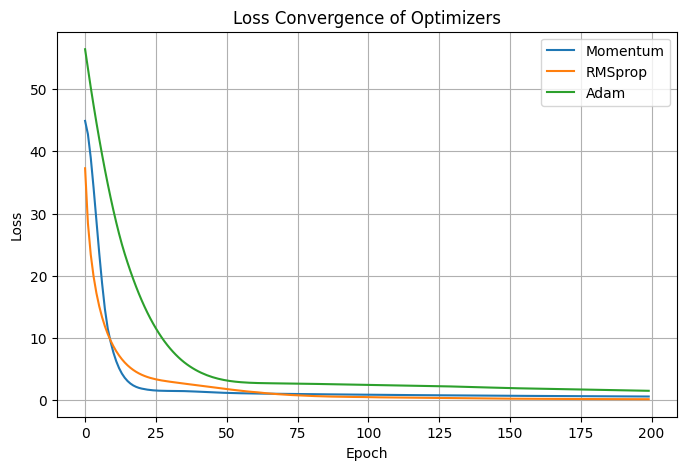

In [18]:
plt.figure(figsize=(8,5))

plt.plot(loss_momentum,label="Momentum")
plt.plot(loss_rmsprop,label="RMSprop")
plt.plot(loss_adam,label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Convergence of Optimizers")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Final Losses
print("Final Momentum Loss :", loss_momentum[-1])
print("Final RMSprop Loss  :", loss_rmsprop[-1])
print("Final Adam Loss     :", loss_adam[-1])

Final Momentum Loss : 0.6121036410331726
Final RMSprop Loss  : 0.1781252920627594
Final Adam Loss     : 1.531585693359375
